# Preprocessing — Country-Year Panel for Regression & Causal Direction Analysis

Builds a clean country-year parquet panel for Vlad's regression work and Edoardo's
causal-direction (lead-lag) analysis. See `notes_for_report.md` at the repo root for
the full methodology write-up; this notebook implements those decisions.

**Methodological decisions (fixed, not re-derived here):**
- Window: 1970-2019 (V-Party expert-coding window).
- Populism aggregation: senior governing party (`v2pagovsup == 0`); when a country-year
  has more than one senior governing party (coalitions), use the vote-share-weighted
  mean if vote share is available for all parties in that group, otherwise the simple
  mean.
- Forward-fill: populism held constant from an election year to the next election.
- Quality filter: drop cells with low coder counts (`_nr <= 3`).
- Join: inner join on `(country_id, year)` with V-Dem.
- Treatment: populism is **continuous** throughout — no binary cutoff baked into this panel.

## Section 0 — Setup & connection

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid")

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)

ANALYSIS_START_YEAR = 1970
ANALYSIS_END_YEAR = 2019

DB_PATH = Path("../data/duckdb/vdem.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)

pl.read_database("SELECT table_schema, table_name FROM information_schema.tables ORDER BY 1, 2", con)

table_schema,table_name
str,str
"""meta""","""analysis_window"""
"""meta""","""import_summary"""
"""raw""","""vdem_country_year"""
"""raw""","""vparty_country_party_date"""


## Section 1 — V-Party aggregation to country-year

### 1a. Senior governing parties, 1970-2019, coder-count filtered

`v2xpa_popul` is a Type-D index (built from `v2paanteli` + `v2papeople`) and has no `_nr`
of its own — D-indices don't carry coder counts (see `measurement-model.md`). The
coder-count filter is applied to its two *component* C-variables instead: both
`v2paanteli_nr` and `v2papeople_nr` must be `> 3`.

In [2]:
gov_raw = pl.read_database(
    f"""
    SELECT country_id, year, country_name, v2paenname, v2xpa_popul, v2pavote
    FROM raw.vparty_country_party_date
    WHERE v2pagovsup = 0
      AND year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2xpa_popul IS NOT NULL
      AND v2paanteli_nr > 3
      AND v2papeople_nr > 3
    """,
    con,
)
gov_raw.shape

(953, 6)

### 1b. Aggregate to (country_id, year): vote-share-weighted mean, falling back to simple mean

Most country-years have exactly one senior governing party. For coalition country-years
with more than one, the weighted mean is used only when *every* party in that group has
a non-null `v2pavote` and the vote shares sum to something positive; otherwise the
simple mean is used.

In [3]:
gov_agg = (
    gov_raw.group_by(["country_id", "year"])
    .agg([
        pl.col("country_name").first(),
        pl.col("v2paenname").sort().str.join(" / ").alias("party_names"),
        pl.len().alias("n_senior_gov_parties"),
        pl.col("v2xpa_popul").mean().alias("_popul_simple_mean"),
        pl.col("v2pavote").null_count().alias("_n_null_vote"),
        pl.col("v2pavote").sum().alias("_vote_sum"),
        (pl.col("v2xpa_popul") * pl.col("v2pavote")).sum().alias("_weighted_num"),
    ])
    .with_columns(
        pl.when((pl.col("_n_null_vote") == 0) & (pl.col("_vote_sum") > 0))
        .then(pl.col("_weighted_num") / pl.col("_vote_sum"))
        .otherwise(pl.col("_popul_simple_mean"))
        .alias("populism_governing")
    )
    .select([
        "country_id", "year", "country_name", "party_names",
        "n_senior_gov_parties", "populism_governing",
    ])
)
gov_agg.filter(pl.col("n_senior_gov_parties") > 1)

country_id,year,country_name,party_names,n_senior_gov_parties,populism_governing
i64,i64,str,str,u32,f64
17,1980,"""Poland""","""Front of National Unity / Poli…",2,0.1965
134,1994,"""Togo""","""Rally of the Togolese People /…",2,0.334
17,1972,"""Poland""","""Front of National Unity / Poli…",2,0.1965
78,1978,"""Guatemala""","""Democratic Institutional Party…",2,0.1165
55,1993,"""Cambodia""","""Cambodian Peoples' Party / Kam…",2,0.303343
78,2015,"""Guatemala""","""National Convergence Front / P…",2,0.216464
17,1985,"""Poland""","""Patriotic Movement for Nationa…",2,0.1985
17,1976,"""Poland""","""Front of National Unity / Poli…",2,0.1965


### 1c/1d. Head and shape

In [4]:
print("shape:", gov_agg.shape)
gov_agg.head()

shape: (945, 6)


country_id,year,country_name,party_names,n_senior_gov_parties,populism_governing
i64,i64,str,str,u32,f64
75,1994,"""Ecuador""","""Republican Unity Party""",1,0.2
105,2012,"""Armenia""","""Republican Party of Armenia""",1,0.127
120,1972,"""Jamaica""","""People's National Party""",1,0.485
173,2008,"""Lithuania""","""Homeland Union / Homeland Unio…",1,0.131
98,1999,"""Tunisia""","""Neo Destour / New Constitution…",1,0.268


## Section 2 — Forward-fill between elections

### 2a/2b. Fill years between elections; flag election years and years-since-election

In [5]:
year_grid = pl.DataFrame({"year": list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))})
country_grid = gov_agg.select("country_id").unique()
full_grid = country_grid.join(year_grid, how="cross")

panel_popul = (
    full_grid
    .join(gov_agg, on=["country_id", "year"], how="left")
    .sort(["country_id", "year"])
    .with_columns(pl.col("populism_governing").is_not_null().alias("is_election_year"))
    .with_columns(
        pl.when(pl.col("is_election_year")).then(pl.col("year")).alias("_last_election_year")
    )
    .with_columns([
        pl.col("populism_governing").forward_fill().over("country_id"),
        pl.col("party_names").forward_fill().over("country_id"),
        pl.col("n_senior_gov_parties").forward_fill().over("country_id"),
        pl.col("country_name").forward_fill().over("country_id"),
        pl.col("_last_election_year").forward_fill().over("country_id"),
    ])
    .with_columns((pl.col("year") - pl.col("_last_election_year")).alias("years_since_last_election"))
    .drop("_last_election_year")
    .filter(pl.col("populism_governing").is_not_null())  # drop years before a country's first coded election
)
panel_popul.head()

country_id,year,country_name,party_names,n_senior_gov_parties,populism_governing,is_election_year,years_since_last_election
i64,i64,str,str,u32,f64,bool,i64
3,1970,"""Mexico""","""Institutional Revolutionary Pa…",1,0.199,true,0
3,1971,"""Mexico""","""Institutional Revolutionary Pa…",1,0.199,false,1
3,1972,"""Mexico""","""Institutional Revolutionary Pa…",1,0.199,false,2
3,1973,"""Mexico""","""Institutional Revolutionary Pa…",1,0.196,true,0
3,1974,"""Mexico""","""Institutional Revolutionary Pa…",1,0.196,false,1


### 2c. Rows added by forward-fill

In [6]:
n_total = panel_popul.height
n_election_years = panel_popul["is_election_year"].sum()
n_forward_filled = n_total - n_election_years
print(f"total rows: {n_total}")
print(f"raw election-year rows: {n_election_years}")
print(f"forward-filled rows added: {n_forward_filled} ({100*n_forward_filled/n_total:.1f}%)")

total rows: 3965
raw election-year rows: 945
forward-filled rows added: 3020 (76.2%)


## Section 3 — Join with V-Dem & add controls

⚠️ **Direction note:** `v2lgcrrpt`/`v2jucorrdc` are kept here as V-Dem's plain latent
estimates (continuous, ~z-scale, roughly −3…+4) — the right scale for regression, but
their direction is **higher = cleaner**, the opposite of `v2x_corr`/`v2x_execorr`/
`v2x_pubcorr` (0-1, higher = more corrupt). See `notes_for_report.md` for the EDA-stage
rescaled version used for plotting; this parquet intentionally keeps the original scale
so no resolution is lost, and flags the sign difference instead (see Section 7).

In [7]:
vdem_vars = pl.read_database(
    f"""
    SELECT country_id, year, country_name,
           v2x_corr, v2x_execorr, v2x_pubcorr, v2lgcrrpt, v2jucorrdc,
           e_gdppc, v2x_polyarchy, e_regiongeo, e_pop
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    """,
    con,
).rename({"country_name": "country_name_vdem"})

panel = (
    panel_popul.join(vdem_vars, on=["country_id", "year"], how="inner")
    .with_columns(pl.col("e_gdppc").log().alias("log_gdppc"))
    .with_columns(pl.col("country_name_vdem").alias("country_name"))
    .drop("country_name_vdem")
)
panel.shape

(3965, 18)

### Countries/rows lost to the inner join

In [8]:
lost = panel_popul.join(vdem_vars, on=["country_id", "year"], how="anti")
print(f"rows in populism panel before join: {panel_popul.height}")
print(f"rows lost (no matching V-Dem country-year): {lost.height}")
(
    lost.group_by(["country_id", "country_name"]).agg(pl.len().alias("n_rows_lost"))
    .sort("n_rows_lost", descending=True)
    .head(10)
)

rows in populism panel before join: 3965
rows lost (no matching V-Dem country-year): 0


country_id,country_name,n_rows_lost
i64,str,u32


## Section 4 — Create lagged (and lead) variables

⚠️ `.shift()` assumes a complete, gap-free annual sequence per country. V-Dem's
country-year coverage in this window is close to complete (Section 1a's coverage check),
so a `shift(k)` is treated as "k years ago" — but any country with a missing year inside
its run would silently get a lag from the *previous available row*, not literally k
calendar years back. Worth re-checking before Edoardo's lead-lag regressions lean on this.

In [9]:
LAG_YEARS = [1, 2, 3, 5]
LEAD_YEARS = [1, 2, 3]

panel = panel.sort(["country_id", "year"])

for k in LAG_YEARS:
    panel = panel.with_columns([
        pl.col("populism_governing").shift(k).over("country_id").alias(f"populism_governing_lag{k}"),
        pl.col("v2x_corr").shift(k).over("country_id").alias(f"v2x_corr_lag{k}"),
    ])

for k in LEAD_YEARS:
    panel = panel.with_columns(
        pl.col("populism_governing").shift(-k).over("country_id").alias(f"populism_governing_lead{k}")
    )

panel.select([c for c in panel.columns if "lag" in c or "lead" in c]).head()

populism_governing_lag1,v2x_corr_lag1,populism_governing_lag2,v2x_corr_lag2,populism_governing_lag3,v2x_corr_lag3,populism_governing_lag5,v2x_corr_lag5,populism_governing_lead1,populism_governing_lead2,populism_governing_lead3
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
null,null,null,null,null,null,null,null,0.199,0.199,0.196
0.199,0.82,null,null,null,null,null,null,0.199,0.196,0.196
0.199,0.82,0.199,0.82,null,null,null,null,0.196,0.196,0.196
0.199,0.82,0.199,0.82,0.199,0.82,null,null,0.196,0.196,0.131
0.196,0.82,0.199,0.82,0.199,0.82,null,null,0.196,0.131,0.131


## Section 5 — Quality checks & summary

In [10]:
print("final shape:", panel.shape)
print("distinct countries:", panel["country_id"].n_unique())
print("year range:", panel["year"].min(), "-", panel["year"].max())

final shape: (3965, 29)
distinct countries: 96
year range: 1970 - 2019


In [11]:
KEY_VARS = [
    "populism_governing", "v2x_corr", "v2x_execorr", "v2x_pubcorr",
    "v2lgcrrpt", "v2jucorrdc", "e_gdppc", "log_gdppc", "v2x_polyarchy",
    "e_regiongeo", "e_pop",
]
missing = pl.DataFrame({
    "variable": KEY_VARS,
    "n_missing": [panel[v].null_count() for v in KEY_VARS],
    "pct_missing": [round(100 * panel[v].null_count() / panel.height, 1) for v in KEY_VARS],
})
missing

variable,n_missing,pct_missing
str,i64,f64
"""populism_governing""",0,0.0
"""v2x_corr""",0,0.0
"""v2x_execorr""",0,0.0
"""v2x_pubcorr""",0,0.0
"""v2lgcrrpt""",195,4.9
"""v2jucorrdc""",0,0.0
"""e_gdppc""",25,0.6
"""log_gdppc""",25,0.6
"""v2x_polyarchy""",0,0.0


### 5e. Cross-sectional correlations: populism vs. the 5 corruption dimensions

Cross-sectional correlations across all country-years (1970-2019). This is descriptive only — country & year fixed effects (Vlad's regression) are needed to isolate within-country variation from between-country structural differences.

Reminder: `v2lgcrrpt`/`v2jucorrdc` keep V-Dem's original direction (higher = *cleaner*), opposite to `v2x_corr`/`v2x_execorr`/`v2x_pubcorr` (higher = more corrupt) — see Section 3/7. So a *negative* correlation between `populism_governing` and `v2lgcrrpt`/`v2jucorrdc` means the same thing as a *positive* correlation for the other three: more populism, more corruption.

In [12]:
from scipy.stats import spearmanr

CORR_VARS = ["populism_governing", "v2x_corr", "v2x_execorr", "v2x_pubcorr", "v2lgcrrpt", "v2jucorrdc"]

corr_data = panel.select(CORR_VARS).drop_nulls()
corr_arr = corr_data.to_numpy()

pearson_corr = pl.DataFrame(
    np.corrcoef(corr_arr, rowvar=False), schema=CORR_VARS
).insert_column(0, pl.Series("variable", CORR_VARS))

spearman_arr, _ = spearmanr(corr_arr)
spearman_corr = pl.DataFrame(
    spearman_arr, schema=CORR_VARS
).insert_column(0, pl.Series("variable", CORR_VARS))

print(f"n complete-case rows: {corr_data.height}")
print("\nPearson:")
print(pearson_corr)
print("\nSpearman:")
print(spearman_corr)

n complete-case rows: 3770

Pearson:
shape: (6, 7)
┌────────────────┬────────────────┬───────────┬─────────────┬─────────────┬───────────┬────────────┐
│ variable       ┆ populism_gover ┆ v2x_corr  ┆ v2x_execorr ┆ v2x_pubcorr ┆ v2lgcrrpt ┆ v2jucorrdc │
│ ---            ┆ ning           ┆ ---       ┆ ---         ┆ ---         ┆ ---       ┆ ---        │
│ str            ┆ ---            ┆ f64       ┆ f64         ┆ f64         ┆ f64       ┆ f64        │
│                ┆ f64            ┆           ┆             ┆             ┆           ┆            │
╞════════════════╪════════════════╪═══════════╪═════════════╪═════════════╪═══════════╪════════════╡
│ populism_gover ┆ 1.0            ┆ 0.116091  ┆ 0.116175    ┆ 0.101272    ┆ -0.10587  ┆ -0.130192  │
│ ning           ┆                ┆           ┆             ┆             ┆           ┆            │
│ v2x_corr       ┆ 0.116091       ┆ 1.0       ┆ 0.947753    ┆ 0.940411    ┆ -0.875006 ┆ -0.916279  │
│ v2x_execorr    ┆ 0.116175       ┆ 0.94

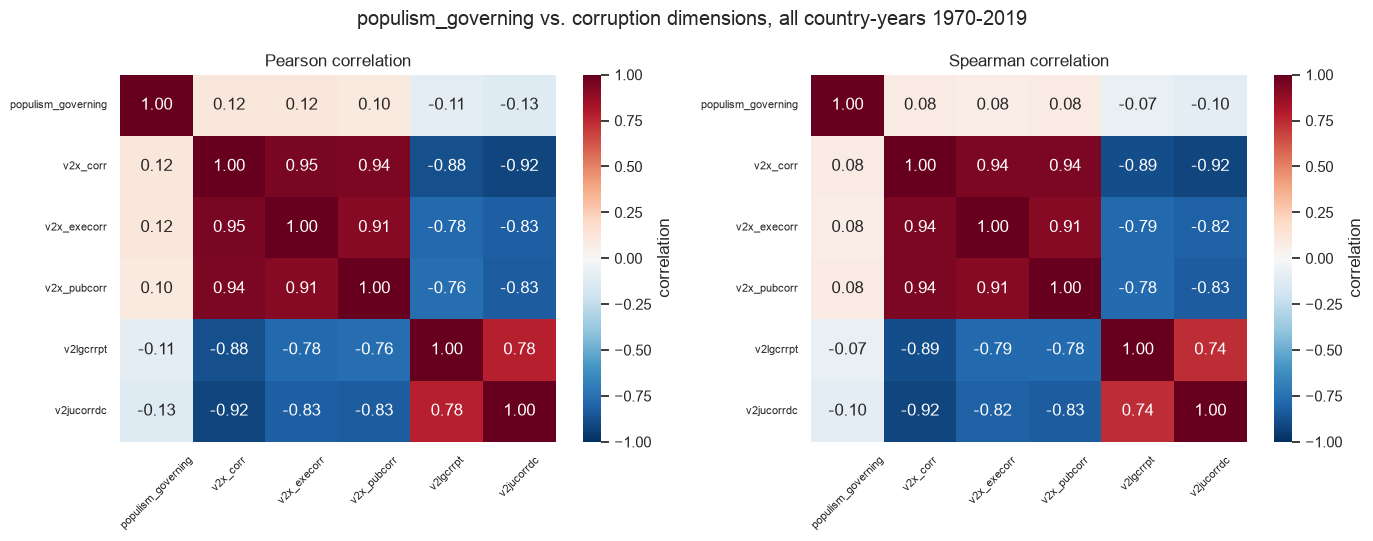

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (mat, title) in zip(
    axes,
    [(pearson_corr.select(CORR_VARS).to_numpy(), "Pearson"),
     (spearman_corr.select(CORR_VARS).to_numpy(), "Spearman")],
):
    sns.heatmap(
        mat, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
        xticklabels=CORR_VARS, yticklabels=CORR_VARS, ax=ax,
        cbar_kws={"label": "correlation"},
    )
    ax.set_title(f"{title} correlation")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
fig.suptitle("populism_governing vs. corruption dimensions, all country-years 1970-2019")
fig.tight_layout()
plt.show()

### 5f. Preliminary read: is the relationship positive, and which dimension correlates most?

- **Yes, positive across the board.** Once `v2lgcrrpt`/`v2jucorrdc`'s sign is flipped to the common "higher = more corrupt" direction, `populism_governing` correlates positively with all five corruption measures, both Pearson and Spearman — but every coefficient is **small** (|r| ≈ 0.07-0.13).
- **Judicial corruption (`v2jucorrdc`) shows the strongest correlation with populism** (Pearson r≈-0.13, i.e. +0.13 in the more-corrupt direction), followed by the composite `v2x_corr` and `v2x_execorr` (both ≈0.116); `v2x_pubcorr` and `v2lgcrrpt` are weakest (≈0.10-0.11). This roughly echoes Section 4c's Mann-Whitney result from the EDA notebook (legislative and judicial showed the largest group-difference effect sizes), with judicial corruption the more consistent signal across both methods.
- ⚠️ **This informs Vlad's starting hypothesis for the regression (small, positive, judicial/composite-leaning effect) — it is not a test of anything.** These are raw cross-sectional correlations pooling all 96 countries and 50 years together; they cannot separate a real within-country relationship from between-country confounding (region, regime type, GDP — see the EDA notebook's Section 3d) or say anything about which way the relationship runs. That is exactly what the fixed-effects regression and lead-lag design are for.

### Distribution of `populism_governing` after forward-fill — distorted vs. raw election-year values?

In [14]:
raw_dist = gov_agg["populism_governing"]
ffilled_dist = panel["populism_governing"]

pl.DataFrame({
    "version": ["raw (election years only)", "forward-filled (final panel)"],
    "n": [raw_dist.len(), ffilled_dist.len()],
    "mean": [raw_dist.mean(), ffilled_dist.mean()],
    "median": [raw_dist.median(), ffilled_dist.median()],
    "std": [raw_dist.std(), ffilled_dist.std()],
    "skew": [raw_dist.skew(), ffilled_dist.skew()],
})

version,n,mean,median,std,skew
str,i64,f64,f64,f64,f64
"""raw (election years only)""",945,0.330551,0.271,0.232326,0.923204
"""forward-filled (final panel)""",3965,0.342095,0.276,0.238422,0.861698


### Top/bottom 5 countries by mean populism and mean corruption

In [15]:
by_country = panel.group_by(["country_id", "country_name"]).agg([
    pl.col("populism_governing").mean().alias("mean_populism"),
    pl.col("v2x_corr").mean().alias("mean_corruption"),
])

print("Top 5 by mean populism:")
print(by_country.sort("mean_populism", descending=True).head(5))
print("\nBottom 5 by mean populism:")
print(by_country.sort("mean_populism").head(5))
print("\nTop 5 by mean corruption:")
print(by_country.sort("mean_corruption", descending=True).head(5))
print("\nBottom 5 by mean corruption:")
print(by_country.sort("mean_corruption").head(5))

Top 5 by mean populism:
shape: (5, 4)
┌────────────┬──────────────┬───────────────┬─────────────────┐
│ country_id ┆ country_name ┆ mean_populism ┆ mean_corruption │
│ ---        ┆ ---          ┆ ---           ┆ ---             │
│ i64        ┆ str          ┆ f64           ┆ f64             │
╞════════════╪══════════════╪═══════════════╪═════════════════╡
│ 124        ┆ Libya        ┆ 0.906204      ┆ 0.848082        │
│ 155        ┆ Cuba         ┆ 0.80252       ┆ 0.58282         │
│ 38         ┆ Ethiopia     ┆ 0.749242      ┆ 0.540303        │
│ 51         ┆ Venezuela    ┆ 0.698787      ┆ 0.797404        │
│ 97         ┆ Syria        ┆ 0.671766      ┆ 0.874234        │
└────────────┴──────────────┴───────────────┴─────────────────┘

Bottom 5 by mean populism:
shape: (5, 4)
┌────────────┬──────────────┬───────────────┬─────────────────┐
│ country_id ┆ country_name ┆ mean_populism ┆ mean_corruption │
│ ---        ┆ ---          ┆ ---           ┆ ---             │
│ i64        ┆ str      

## Section 6 — Save to parquet

In [16]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PARQUET_PATH = PROCESSED_DIR / "panel_populism_corruption.parquet"
CSV_PREVIEW_PATH = PROCESSED_DIR / "panel_preview.csv"

panel.write_parquet(PARQUET_PATH)
panel.head(100).write_csv(CSV_PREVIEW_PATH)

print(f"parquet size: {PARQUET_PATH.stat().st_size / 1024:.1f} KB")
print(f"csv preview size: {CSV_PREVIEW_PATH.stat().st_size / 1024:.1f} KB")

parquet size: 160.8 KB
csv preview size: 21.8 KB


In [17]:
import pandas as pd

test_df = pd.read_parquet(PARQUET_PATH)
print("pandas read_parquet OK — shape:", test_df.shape)
test_df.head()

pandas read_parquet OK — shape: (3965, 29)


,country_id,year,country_name,party_names,n_senior_gov_parties,populism_governing,is_election_year,years_since_last_election,v2x_corr,v2x_execorr,...,v2x_corr_lag1,populism_governing_lag2,v2x_corr_lag2,populism_governing_lag3,v2x_corr_lag3,populism_governing_lag5,v2x_corr_lag5,populism_governing_lead1,populism_governing_lead2,populism_governing_lead3
0,3,1970,Mexico,Institutional Revolutionary Party,1,0.199,True,0,0.82,0.836,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.199,0.199,0.196
1,3,1971,Mexico,Institutional Revolutionary Party,1,0.199,False,1,0.82,0.836,...,0.82,NaN,NaN,NaN,NaN,NaN,NaN,0.199,0.196,0.196
2,3,1972,Mexico,Institutional Revolutionary Party,1,0.199,False,2,0.82,0.836,...,0.82,0.199,0.82,NaN,NaN,NaN,NaN,0.196,0.196,0.196
3,3,1973,Mexico,Institutional Revolutionary Party,1,0.196,True,0,0.82,0.836,...,0.82,0.199,0.82,0.199,0.82,NaN,NaN,0.196,0.196,0.131
4,3,1974,Mexico,Institutional Revolutionary Party,1,0.196,False,1,0.82,0.836,...,0.82,0.199,0.82,0.199,0.82,NaN,NaN,0.196,0.131,0.131


## Section 7 — Data dictionary

| Column | Description |
|---|---|
| `country_id` | V-Dem/V-Party numeric country identifier (join key). |
| `year` | Calendar year, 1970-2019. |
| `country_name` | Country name (from V-Dem; V-Party's spelling for the same `country_id` can differ, e.g. "Türkiye" vs "Turkey" — see Section 5 case studies in `01_eda_populism_corruption.ipynb`). |
| `populism_governing` | Populism score of the senior governing party (`v2pagovsup==0`), vote-share-weighted mean across coalition partners (falls back to simple mean), forward-filled between elections. Continuous, 0-1, higher = more populist. **Primary treatment variable.** |
| `party_names` | Senior governing party name(s) at the most recent election (`/`-joined if a coalition); forward-filled like `populism_governing`. Context only, not for modeling. |
| `n_senior_gov_parties` | Number of senior governing parties coded in that election year (1 unless a coalition). |
| `is_election_year` | `True` if this row is a raw V-Party election observation; `False` if forward-filled. |
| `years_since_last_election` | Years elapsed since the election that set the current `populism_governing` value (0 in election years). |
| `v2x_corr` | Composite political corruption index (V-Dem D-index), 0-1, **higher = more corrupt**. |
| `v2x_execorr` | Executive corruption index, 0-1, higher = more corrupt. |
| `v2x_pubcorr` | Public-sector corruption index, 0-1, higher = more corrupt. |
| `v2lgcrrpt` | Legislative corruption, plain latent estimate (~z-scale, roughly −3…+4). ⚠️ **higher = cleaner** — opposite direction from the `v2x_*` indices above. Missing for countries/years without a legislature. |
| `v2jucorrdc` | Judicial corruption, plain latent estimate (~z-scale). ⚠️ **higher = cleaner** — same reversed direction as `v2lgcrrpt`. |
| `e_gdppc` | GDP per capita (V-Dem external/Type-E variable), raw scale. |
| `log_gdppc` | Natural log of `e_gdppc` — the control variable named in the brief ("log GDP per capita"). |
| `v2x_polyarchy` | Electoral democracy index, 0-1, higher = more democratic. |
| `e_regiongeo` | UN geoscheme region code (19 categories) — see `01_eda_populism_corruption.ipynb` Section 2d for the label mapping. |
| `e_pop` | Population (V-Dem external/Type-E variable). |
| `populism_governing_lag{1,2,3,5}` | `populism_governing` shifted back k years within country (assumes a gap-free annual sequence — see Section 4's caveat). |
| `v2x_corr_lag{1,2,3,5}` | `v2x_corr` shifted back k years within country, for Edoardo's Granger-style direction tests. |
| `populism_governing_lead{1,2,3}` | `populism_governing` shifted forward k years within country — supports testing the reverse direction (does corruption predict *future* populism?). |
